EXPERIMENT:
SEQ_LEN = 336
PRED_LEN = 48

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import json

In [2]:
X_train = torch.load("../../01_dataset/preprocessed-2/X_train.pt")
y_train = torch.load("../../01_dataset/preprocessed-2/y_train.pt")

X_val = torch.load("../../01_dataset/preprocessed-2/X_val.pt")
y_val = torch.load("../../01_dataset/preprocessed-2/y_val.pt")

X_test = torch.load("../../01_dataset/preprocessed-2/X_test.pt")
y_test = torch.load("../../01_dataset/preprocessed-2/y_test.pt")

print(X_train.shape)

torch.Size([11810, 336, 7])


HYPERPARAMETER

In [3]:
INPUT_DIM = X_train.shape[2]
D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
OUTPUT_DIM = 48

LR = 0.0001
EPOCHS = 20
BATCH_SIZE = 32

MODEL

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [5]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, output_dim):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        x = self.transformer(x)

        x = x[:, -1, :]
        x = self.fc(x)

        return x

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TransformerModel(
    INPUT_DIM, D_MODEL, NHEAD, NUM_LAYERS, OUTPUT_DIM
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [7]:
num_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", num_params)

Total parameters: 565936


TRAINING

In [8]:
history = []

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for i in range(0, len(X_train), BATCH_SIZE):
        X_batch = X_train[i:i+BATCH_SIZE].to(device)
        y_batch = y_train[i:i+BATCH_SIZE].to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(X_train)

    # VALIDATION
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val.to(device))
        val_loss = criterion(val_outputs, y_val.to(device)).item()

    history.append([epoch, train_loss, val_loss])

    print(f"Epoch {epoch+1}, Train: {train_loss:.4f}, Val: {val_loss:.4f}")

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.4f} seconds")

Epoch 1, Train: 0.0174, Val: 0.4893
Epoch 2, Train: 0.0245, Val: 0.4709
Epoch 3, Train: 0.0162, Val: 0.3654
Epoch 4, Train: 0.0114, Val: 0.3035
Epoch 5, Train: 0.0090, Val: 0.2690
Epoch 6, Train: 0.0078, Val: 0.2458
Epoch 7, Train: 0.0069, Val: 0.2307
Epoch 8, Train: 0.0063, Val: 0.2301
Epoch 9, Train: 0.0058, Val: 0.2348
Epoch 10, Train: 0.0054, Val: 0.2338
Epoch 11, Train: 0.0050, Val: 0.2206
Epoch 12, Train: 0.0048, Val: 0.2089
Epoch 13, Train: 0.0046, Val: 0.2015
Epoch 14, Train: 0.0045, Val: 0.2030
Epoch 15, Train: 0.0043, Val: 0.2083
Epoch 16, Train: 0.0042, Val: 0.1955
Epoch 17, Train: 0.0041, Val: 0.2061
Epoch 18, Train: 0.0040, Val: 0.2066
Epoch 19, Train: 0.0039, Val: 0.2298
Epoch 20, Train: 0.0038, Val: 0.1963
Training time: 356.4917 seconds


In [9]:
history_df = pd.DataFrame(history, columns=["epoch", "train_loss", "val_loss"])
history_df.to_csv("result-2/transformer_history.csv", index=False)

In [10]:
model.eval()

with torch.no_grad():
    preds = model(X_test.to(device)).cpu().numpy()
    true = y_test.numpy()

mae = np.mean(np.abs(preds - true))
mse = np.mean((preds - true)**2)
rmse = np.sqrt(mse)

print(mae, mse, rmse)

0.21265954 0.07217619 0.26865625


In [11]:
metrics_df = pd.DataFrame([[mae, mse, rmse]], columns=["MAE", "MSE", "RMSE"])
metrics_df.to_csv("result-2/transformer_metrics.csv", index=False)

In [12]:
pred_df = pd.DataFrame({
    "y_true": true.flatten(),
    "y_pred": preds.flatten()
})

pred_df.to_csv("result-2/transformer_predictions.csv", index=False)

In [13]:
config = {
    "model": "Transformer",
    "seq_len": 336,
    "pred_len": 48,
    "input_dim": INPUT_DIM,
    "d_model": D_MODEL,
    "nhead": NHEAD,
    "num_layers": NUM_LAYERS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "epochs": EPOCHS,
    "num_parameters": num_params,
    "training_time_seconds": training_time
}

with open("result-2/transformer_config.json", "w") as f:
    json.dump(config, f, indent=4)

PLOT

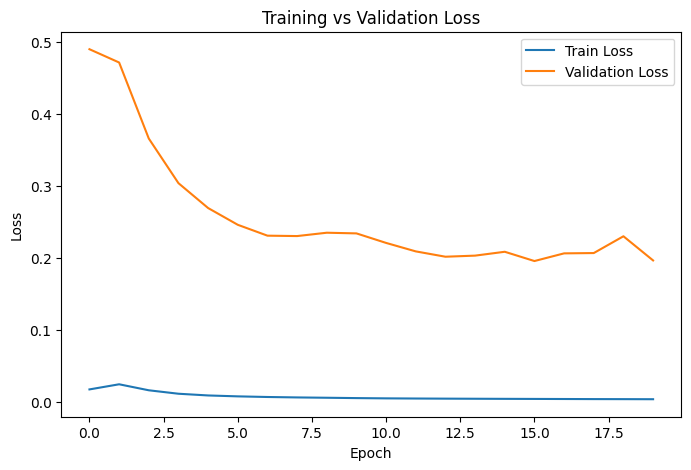

In [14]:
history = pd.read_csv("result-2/transformer_history.csv")

plt.figure(figsize=(8,5))

plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

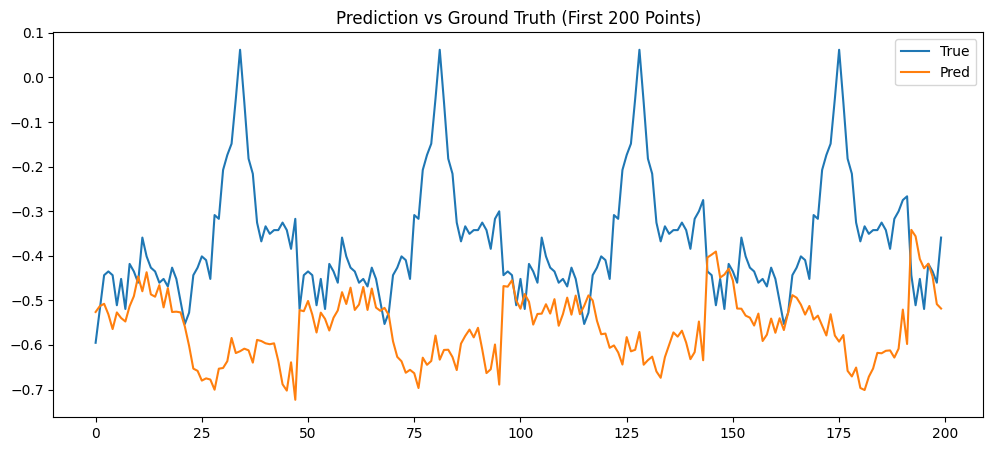

In [15]:
pred_df = pd.read_csv("result-2/transformer_predictions.csv")

y_true = pred_df["y_true"].values
y_pred = pred_df["y_pred"].values

plt.figure(figsize=(12,5))

plt.plot(y_true[:200], label="True")
plt.plot(y_pred[:200], label="Pred")

plt.title("Prediction vs Ground Truth (First 200 Points)")
plt.legend()

plt.show()

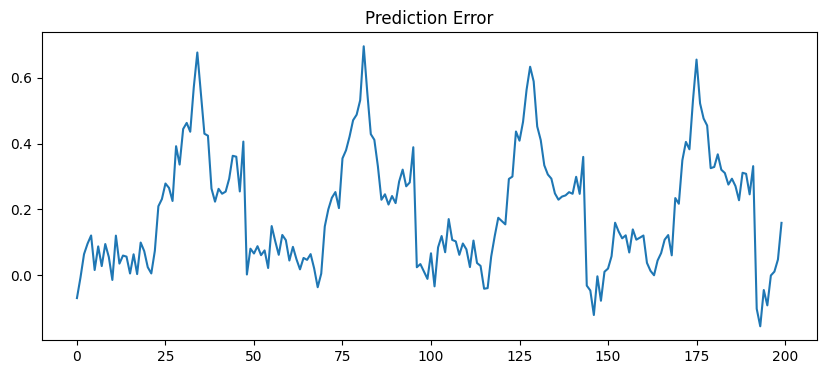

In [16]:
error = y_true - y_pred

plt.figure(figsize=(10,4))
plt.plot(error[:200])
plt.title("Prediction Error")
plt.show()